# Biotech/Pharma Stock Volatility

I read recently, in the book *Inside the Black Box* by Rishi Narang, that quantitative 
researchers typically are not interested in biotechnology stocks. The specific
passage was: 

>  Third, quants tend to prefer instruments that behave in a
manner conducive to being predicted by systematic models. Returning to
the example of biotechnology stocks, some quants exclude them because
they are subject to sudden, violent price changes based on events such as
government approval or rejection of their latest drug.

The goal of this project is to quantify and visualise whether or not this is actually 
true

In [1]:
import yfinance as yf
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

## Choice of Stocks

Our goal is to illustrate sudden prices moves, primarily from approval/rejection events.
Therefore, it would be useful to focus on candidates that: 
- are small, because larger companies (typically) have a more diversified set of pipelines/projects,
- have a history of these sources (just easier to identify this way). 

Note/disclaimer: for the second point I did use an LLM to help me generate some 
tickers, as I am not particularly familiar with the history beyond some obvious
ones (e.g. BioNTech with the COVID-19 vaccine). Obviously it would be more thorough
to go through primary sources released by e.g. the FDA, but this is a side project 
so rigour is important but not paramount. :^)

In [2]:
TICKERS = {
    # "boring" big pharma contrast
    "PFE": "Pfizer",
    # larger company, but still saw big swings during the pandemic
    "MRNA": "Moderna",
    # for the most part stable, as it is a big pharma company, but has Alzeimer edge case
    "LLY": "Eli Lilly",
    # COVID
    "BNTX": "BioNTech",
    # DMD gene therapy
    "SRPT": "Sarepta",
    # Aduhelm Alzeimer's controversy 2023
    "BIIB": "Biogen",
    # late covid vaccine, extreme binary event
    "NVAX": "Novavax",
    # resmetiron NASH approval 2024
    "MDGL": "Madrigal Pharmaceuticals",
    # ETF baseline: is even the basket volatile?
    "XBI": "SPDR S&P Biotech ETF",

    # "REGN": "Regeneron",
    # "VRTX": "Vertex",
    # "ALNY": "Alnylam",
}

## Plotting Stock Prices

Let's start by simply visualising the stock prices for each of these chosen companies.

In [3]:
def fetch_prices(tickers: list[str], start: str, end: str) -> pd.DataFrame:
    """Use yfinance IPA to fetch the daily-adjusted close prices for `tickers`
    between the dates [start, end)

    Return: Pandas DataFrame indexed by date, one column per ticker
    """
    raw = yf.download(
        tickers, start=start, end=end, auto_adjust=True, progress=False, group_by='column'
    )
    if raw.empty:
        raise ValueError(f"yfinance returned empty data for {tickers} for {start} to {end}")

    close = raw["Close"]
    if isinstance(close, pd.Series):
        close = close.to_frame(name=tickers[0])
    return close.dropna(how="all")

DATE_START = "2018-01-01" # pre-pandemic baseline
DATE_END = "2026-06-01" # roughly current date

In [4]:
# making sure it works as expected...
prices = fetch_prices(list(TICKERS.keys()), DATE_START, DATE_END)
prices

Ticker,BIIB,BNTX,LLY,MDGL,MRNA,NVAX,PFE,SRPT,XBI
Date,,,,,,,,,
2018-01-02,334.170013,NaN,74.897781,97.419998,NaN,26.000000,23.443439,58.250000,86.262939
2018-01-03,339.850006,NaN,75.304626,98.910004,NaN,27.000000,23.617146,58.549999,87.410332
2018-01-04,339.989990,NaN,75.640739,97.879997,NaN,26.400000,23.668613,57.810001,86.401413
2018-01-05,342.489990,NaN,76.569450,96.529999,NaN,25.799999,23.713650,54.869999,86.094780
2018-01-08,329.649994,NaN,76.180275,93.349998,NaN,27.000000,23.449877,54.020000,84.383553
...,...,...,...,...,...,...,...,...,...
2026-05-22,193.759995,92.139999,1065.000000,517.260010,46.880001,9.210000,25.900000,16.799999,131.530884
2026-05-26,193.080002,92.250000,1064.739990,524.280029,47.029999,10.460000,25.850000,16.670000,133.219238
2026-05-27,196.970001,93.000000,1082.920044,527.669983,47.610001,11.090000,26.209999,16.680000,134.318146


Ticker              LLY       NVAX
Date                              
2018-01-02    74.897781  26.000000
2018-01-03    75.304626  27.000000
2018-01-04    75.640739  26.400000
2018-01-05    76.569450  25.799999
2018-01-08    76.180275  27.000000
...                 ...        ...
2026-05-22  1065.000000   9.210000
2026-05-26  1064.739990  10.460000
2026-05-27  1082.920044  11.090000
2026-05-28  1126.800049  10.320000
2026-05-29  1105.000000  10.970000

[2113 rows x 2 columns]


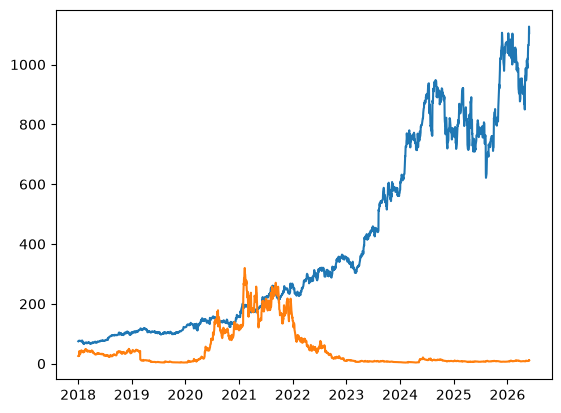

In [5]:
# will likely need to normalise stock prices somehow; see LLY and NVAX as examples
print(prices[['LLY', 'NVAX']])
# fig = go.Figure()
# matplotlib is easier to work with but for putting stuff on website, plotly is nicer
plt.plot(prices['LLY'])
plt.plot(prices['NVAX'])


In [6]:
# Normalize to 100 at first valid date per ticker so different price scales are comparable
# and easier to read and interpret
normalized = prices.div(prices.bfill().iloc[0]) * 100
# normalized = prices

fig = go.Figure()
for ticker, name in TICKERS.items():
    if ticker not in normalized.columns:
        continue
    fig.add_trace(go.Scatter(
        x=normalized.index,
        y=normalized[ticker],
        name=name,
        mode="lines",
        hovertemplate="%{x|%Y-%m-%d}<br>%{y:.1f}<extra>" + name + "</extra>",
    ))

fig.update_layout(
    title="Biotech/Pharma Normalized Price (base 100 = 2018-01-02)",
    xaxis_title="Date",
    yaxis_title="Normalized Price",
    hovermode="x unified",
    legend=dict(orientation="v"),
)
fig.show()


## Events

Now let's add relevant events to the plots and see what happens. Reusing a lot of code here, though of course in practice these should be put in modules/files.

In [9]:
# https://www.fda.gov/news-events/fda-newsroom/press-announcements
# this can likely be automated with an API and/or an LLM to pull and process news articles
# disclaimer: I used an LLM (not a local one) to get most of these press releases,
#   though I did verify them, and in same cases correct them


# It is much easier to find approvals than it is to find rejections (not typically published)
# so I am primarily tracking those
EVENTS = {
    # TODO
    "MRNA": [
    # https://www.fda.gov/vaccines-blood-biologics/spikevax
    ("2022-01-31", "Spikevax Approval"),
    # https://www.fda.gov/media/144434/download
    ("2020-12-17", "Moderna COVID Approval")
        ],
    "PFE": [
        # https://www.fda.gov/news-events/press-announcements/fda-approves-first-covid-19-vaccine
        ("2021-08-23", "COVID-19 Vaccine"),
        # https://www.fda.gov/news-events/press-announcements/coronavirus-covid-19-update-fda-authorizes-first-oral-antiviral-treatment-covid-19
        ("2022-01-31", "COVID-19 Oral Antiviral") # paxlovid
        ],
    "BIIB": [
        # https://www.accessdata.fda.gov/drugsatfda_docs/appletter/2021/761178Orig1s000ltr.pdf
        ("2021-06-07", "Aduhelm Acc. Approval"),
        # https://www.fda.gov/drugs/drug-trials-snapshots/drug-trials-snapshots-leqembi
        ("2023-01-06", "Leqembi Acc. Approval"),
        # https://www.fda.gov/drugs/drug-trials-snapshots/drug-trials-snapshots-leqembi
        ("2023-07-06", "Leqembi Full Approval")
        ],
    "BNTX": [
        # https://www.fda.gov/news-events/press-announcements/fda-approves-first-covid-19-vaccine
        ("2021-08-23", "COVID-19 Vaccine"),
        # https://pmc.ncbi.nlm.nih.gov/articles/PMC7938284/
        ("2020-12-11", "COVID-19 Emergency Approval") # EU and UK limited approval
        ],
    "LLY": [
        # https://www.fda.gov/drugs/news-events-human-drugs/fda-approves-treatment-adults-alzheimers-disease
        ("2024-07-02", "Alzheimer's Treatment")
        ],
    "MDGL": [
        # https://www.fda.gov/news-events/press-announcements/fda-approves-first-treatment-patients-liver-scarring-due-fatty-liver-disease
        ("2024-03-14", "Rezdiffra Approval")
        ],
    "NVAX": [
        # https://www.fda.gov/vaccines-blood-biologics/coronavirus-covid-19-cber-regulated-biologics/novavax-covid-19-vaccine-adjuvanted
        ("2022-07-13", "COVID-19 Emergency Approval")
        ],
    "SRPT": [
        # https://www.fda.gov/media/169715/download
        ("2023-06-22", "DMD Gene Therapy"),
        # https://www.fda.gov/news-events/press-announcements/fda-expands-approval-gene-therapy-patients-duchenne-muscular-dystrophy
        ("2024-06-20", "DMD Therapy Expanded Approval")
        ],
    # XBI is a collection, so no specific events
    "XBI": [],
}